<a href="https://colab.research.google.com/github/mehrshad-sdtn/DeepLearning/blob/master/Papers/Deep_Embedded_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This implementation of the Deep Embedded Clustering **(DEC)** algorithm follows the methodology outlined in the seminal paper "Unsupervised Deep Embedding for Clustering Analysis" by Xie et al. (2016). The DEC algorithm aims to learn a latent space representation that facilitates clustering by leveraging the power of deep neural networks.

Link to paper: https://arxiv.org/abs/1511.06335

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
from tqdm import tqdm
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from scipy.optimize import linear_sum_assignment

In [2]:
os.chdir('/content/drive/MyDrive/LABS')
dir = os.getcwd()
model_path = os.path.join(dir, 'models')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
################################## utils.py ####################################
def imshow(img, title):
    npimg = img.cpu().numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)), interpolation='nearest')
    plt.title(title)
    plt.show()


def cluster_accuracy(y_true, y_pred):
    assert y_true.size == y_pred.size
    D = max(y_pred.max(), y_true.max()) + 1
    w = np.zeros((D, D), dtype=np.int64)
    for i in range(y_true.size):
        w[y_pred[i], y_true[i]] += 1
    ind = linear_sum_assignment(w.max() - w)
    return sum([w[i, j] for i, j in zip(*ind)]) / y_true.size


def target_distribution(batch: torch.Tensor) -> torch.Tensor:
    """
    Compute the target distribution p_ij, given the batch (q_ij), as in 3.1.3 Equation 3 of
    Xie/Girshick/Farhadi; this is used the KL-divergence loss function.

    :param batch: [batch size, number of clusters] Tensor of dtype float
    :return: [batch size, number of clusters] Tensor of dtype float
    """
    weight = (batch ** 2) / torch.sum(batch, 0)
    return (weight.t() / torch.sum(weight, 1)).t()



def encode_latent(encoder, data_loader):
  latent_vectors = []
  latent_labels = []
  with torch.no_grad():
    for data in data_loader:
        img, labels = data
        img = img.to(device)
        encoded = encoder(img.view(-1, 28 * 28))
        latent_vectors.append(encoded.cpu().numpy())
        latent_labels.append(labels.numpy())

  latent_vectors = np.concatenate(latent_vectors)
  latent_labels = np.concatenate(latent_labels)
  return latent_vectors, latent_labels


def plot_latent_space(latent_vectors, latent_labels, caption='t-SNE of Latent Space'):
    tsne = TSNE(n_components=2, random_state=42)
    latent_2d = tsne.fit_transform(latent_vectors)
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=latent_labels, cmap='tab10')
    plt.colorbar(scatter)
    plt.title(caption)
    plt.show()


In [4]:
################################ models.py ###################################
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(28 * 28, 500),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(500, 500),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(500, 2000),
            nn.ReLU(),
            nn.Linear(2000, 10),

        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(10, 2000),
            nn.ReLU(),
            nn.Linear(2000, 500),
            nn.ReLU(),
            nn.Linear(500, 500),
            nn.ReLU(),
            nn.Linear(500, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
      x = x.view(-1, 28 * 28)
      encoded = self.encoder(x)
      decoded = self.decoder(encoded)
      decoded = decoded.view(-1, 1, 28, 28)
      return encoded, decoded



def train_autoencoder(model, train_loader, criterion, optimizer, num_epochs):
  for epoch in range(num_epochs):
    for data in train_loader:
      img, _ = data
      img = img.to(device)

      # Forward
      _, reconstructed = model(img)
      loss = criterion(reconstructed, img)

      # Backward
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')


In [5]:
BATCH = 256
EPOCHS = 300
LEARNING_RATE = 0.0005

transform = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True)

test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH, shuffle=False)

autoencoder = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr= LEARNING_RATE)

In [6]:
train_autoencoder(autoencoder, train_loader, criterion, optimizer, num_epochs= EPOCHS)
torch.save(autoencoder.state_dict(), os.path.join(model_path, f'autoencoder-{EPOCHS}.pth'))

Epoch [1/300], Loss: 0.0510
Epoch [2/300], Loss: 0.0349
Epoch [3/300], Loss: 0.0259
Epoch [4/300], Loss: 0.0248
Epoch [5/300], Loss: 0.0239
Epoch [6/300], Loss: 0.0215
Epoch [7/300], Loss: 0.0177
Epoch [8/300], Loss: 0.0200
Epoch [9/300], Loss: 0.0195
Epoch [10/300], Loss: 0.0153
Epoch [11/300], Loss: 0.0170
Epoch [12/300], Loss: 0.0168
Epoch [13/300], Loss: 0.0177
Epoch [14/300], Loss: 0.0157
Epoch [15/300], Loss: 0.0152
Epoch [16/300], Loss: 0.0152
Epoch [17/300], Loss: 0.0138
Epoch [18/300], Loss: 0.0152
Epoch [19/300], Loss: 0.0144
Epoch [20/300], Loss: 0.0153
Epoch [21/300], Loss: 0.0158
Epoch [22/300], Loss: 0.0159
Epoch [23/300], Loss: 0.0150
Epoch [24/300], Loss: 0.0141
Epoch [25/300], Loss: 0.0152
Epoch [26/300], Loss: 0.0130
Epoch [27/300], Loss: 0.0131
Epoch [28/300], Loss: 0.0145
Epoch [29/300], Loss: 0.0138
Epoch [30/300], Loss: 0.0130
Epoch [31/300], Loss: 0.0131
Epoch [32/300], Loss: 0.0135
Epoch [33/300], Loss: 0.0132
Epoch [34/300], Loss: 0.0121
Epoch [35/300], Loss: 0

In [6]:
trained_autoencoder = Autoencoder()
trained_autoencoder.load_state_dict(torch.load(os.path.join(model_path, f'autoencoder-300.pth')))
trained_autoencoder.to(device)
autoencoder = trained_autoencoder

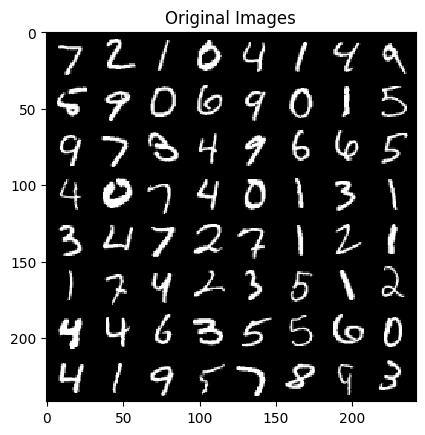

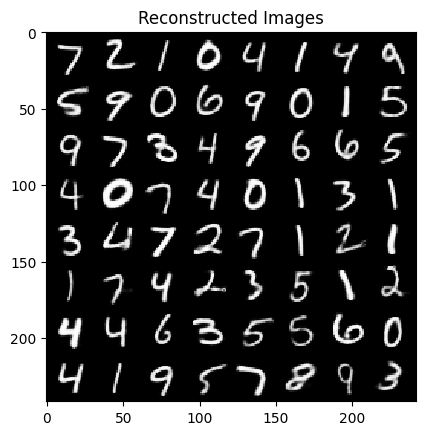

In [7]:
dataiter = iter(test_loader)
images, labels = next(dataiter)
images = images.to(device)


encoded, reconstructed = autoencoder(images)
imshow(torchvision.utils.make_grid(images[:64].cpu()), 'Original Images')
imshow(torchvision.utils.make_grid(reconstructed[:64].detach().cpu()), 'Reconstructed Images')

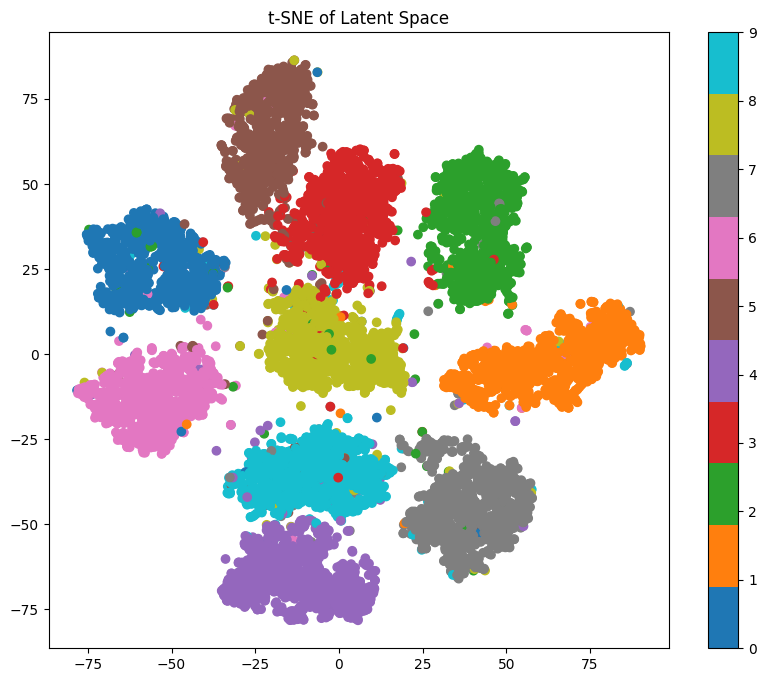

In [8]:
latent_vectors, latent_labels = encode_latent(autoencoder.encoder, test_loader)
plot_latent_space(latent_vectors, latent_labels)

In [9]:
kmeans = KMeans(n_clusters=10, n_init=20, random_state=42)
cluster_labels = kmeans.fit_predict(latent_vectors)

accuracy = cluster_accuracy(latent_labels, cluster_labels)
print(f'Clustering Accuracy: {accuracy * 100:.2f}%')

Clustering Accuracy: 69.92%


In [20]:
from typing import Tuple, Callable, Optional, Union
from torch.utils.data.dataloader import DataLoader, default_collate


class ClusterAssignment(nn.Module):
    def __init__(self, cluster_number: int, embedding_dimension: int, alpha: float = 1.0, cluster_centers: Optional[torch.Tensor] = None) -> None:
        super(ClusterAssignment, self).__init__()
        self.embedding_dimension = embedding_dimension
        self.cluster_number = cluster_number
        self.alpha = alpha
        if cluster_centers is None:
            initial_cluster_centers = torch.zeros(self.cluster_number, self.embedding_dimension, dtype=torch.float)
            nn.init.xavier_uniform_(initial_cluster_centers)
        else:
            initial_cluster_centers = cluster_centers
        self.cluster_centers = nn.Parameter(initial_cluster_centers)

    def forward(self, batch: torch.Tensor) -> torch.Tensor:
        norm_squared = torch.sum((batch.unsqueeze(1) - self.cluster_centers) ** 2, 2)
        numerator = 1.0 / (1.0 + (norm_squared / self.alpha))
        power = float(self.alpha + 1) / 2
        numerator = numerator ** power
        return numerator / torch.sum(numerator, dim=1, keepdim=True)


class DEC(nn.Module):
    def __init__(self, cluster_number: int, hidden_dimension: int, encoder: torch.nn.Module, alpha: float = 1.0):
        super(DEC, self).__init__()
        self.encoder = encoder
        self.hidden_dimension = hidden_dimension
        self.cluster_number = cluster_number
        self.alpha = alpha
        self.assignment = ClusterAssignment(cluster_number, self.hidden_dimension, alpha)

    def forward(self, batch: torch.Tensor) -> torch.Tensor:
        return self.assignment(self.encoder(batch))



def train_dec(model, dataloader, optimizer, num_epochs=50, update_interval=140):
    model.to(device)
    kmeans = KMeans(n_clusters=model.assignment.cluster_number, n_init=20)

    # Initialize cluster centers using KMeans
    data = []
    for x, _ in dataloader:
        x = x.view(-1, 28 * 28)
        data.append(model.encoder(x.to(device)).detach().cpu().numpy())
    data = np.concatenate(data)
    y_pred = kmeans.fit_predict(data)
    model.assignment.cluster_centers.data = torch.tensor(kmeans.cluster_centers_, dtype=torch.float, device=device)

    criterion = nn.KLDivLoss(reduction='batchmean')

    for epoch in range(num_epochs):
        if epoch % update_interval == 0:
            data = []
            labels = []
            for x, y in dataloader:
                x = x.view(-1, 28 * 28)
                data.append(model.encoder(x.to(device)).detach().cpu().numpy())
                labels.append(y.numpy())
            data = np.concatenate(data)
            labels = np.concatenate(labels)
            y_pred = kmeans.fit_predict(data)
            q = model.assignment(torch.tensor(data, dtype=torch.float, device=device))
            p = target_distribution(q).detach().cpu().numpy()
            acc = cluster_accuracy(labels, y_pred)


        for x, _ in tqdm(dataloader):
            x = x.view(-1, 28 * 28)
            x = x.to(device)
            optimizer.zero_grad()
            q = model(x)
            p = target_distribution(q).detach()
            loss = criterion(q.log(), p)
            loss.backward()
            optimizer.step()
        print(f' | Epoch {epoch}, Loss: {loss.item():.4f}, Accuracy: {acc:.4f}')



In [30]:
clustering_model = DEC(cluster_number=10, hidden_dimension=10, encoder=autoencoder.encoder)
optimizer = optim.Adam(clustering_model.parameters(), lr=0.0001)

In [31]:
train_dec(clustering_model, train_loader, optimizer, num_epochs=50)

100%|██████████| 235/235 [00:06<00:00, 33.84it/s]


 | Epoch 0, Loss: 0.0127, Accuracy: 0.7714


100%|██████████| 235/235 [00:06<00:00, 33.87it/s]


 | Epoch 1, Loss: 0.0128, Accuracy: 0.7714


100%|██████████| 235/235 [00:06<00:00, 34.28it/s]


...

 | Epoch 47, Loss: 0.0131, Accuracy: 0.7714


100%|██████████| 235/235 [00:06<00:00, 33.98it/s]


 | Epoch 48, Loss: 0.0124, Accuracy: 0.7714


100%|██████████| 235/235 [00:06<00:00, 33.63it/s]

 | Epoch 49, Loss: 0.0099, Accuracy: 0.7714


**Clustering the data using the DEC trained network**

In [32]:
def cluster_using_dec(model, dataloader):
    model.to(device)  # Ensure the model is on the appropriate device
    model.eval()
    all_features = []
    all_labels = []
    for x, y in dataloader:
        x = x.view(-1, 28 * 28)
        x = x.to(device)
        with torch.no_grad():
            q = model(x)
        all_features.append(q.cpu().numpy())
        all_labels.append(y.numpy())
    all_features = np.concatenate(all_features)
    all_labels = np.concatenate(all_labels)
    y_pred = np.argmax(all_features, axis=1)
    return y_pred, all_labels



# Use the trained DEC model to do clustering
y_pred, y_true = cluster_using_dec(clustering_model, test_loader)

# Calculate and print the final clustering accuracy
final_acc = cluster_accuracy(y_true, y_pred)
print(f'Final Clustering Accuracy: {final_acc * 100:.2f}%')

Final Clustering Accuracy: 77.52%


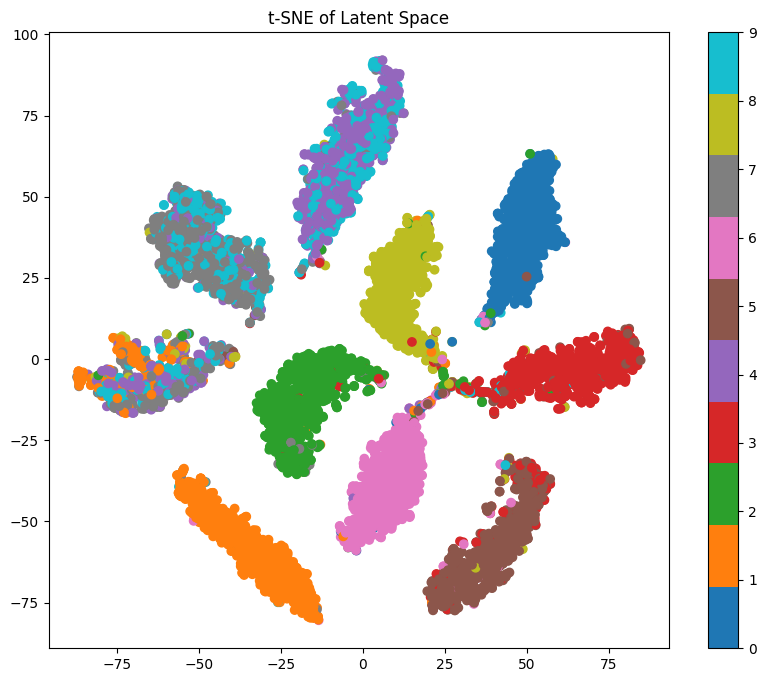

In [33]:
latent_vectors, latent_labels = encode_latent(clustering_model.encoder, test_loader)
plot_latent_space(latent_vectors, latent_labels)

Gained 8 percent improvement over the plain AE + k-means clustering; the note that the original paper pre-trained the autoencoder for **10000 epochs**